In [2]:
import numpy as np
import math as math
import pandas as pd

from numba import njit

from scipy.linalg import hadamard
from numpy import linalg as la

import time
from time import strftime

rng = np.random.default_rng()

Data Gen

In [3]:
rows = 2**10
c = 2**6

In [4]:
normal_params = (rng.normal(loc=0.0, scale=10, size=(rows, c)))
uniform_params = (rng.uniform(low=-10.0, high=10.0, size=(rows, c))) + rng.normal(loc=0.0, scale=1, size=(rows, c))


### CHEM DATA

In [8]:
# Read from chem_data
chem_data = pd.read_csv('C:\\Users\\arjun\\OneDrive\\Desktop\\Random\\Math Club\\Sublime App\\chem_data.csv')
# Last col is response
params = chem_data.to_numpy()[:, :-1]
y = chem_data.to_numpy()[:, -1]
rows, c = params.shape

### Ignore this for now

In [ ]:

weights = rng.normal(loc=0.0, scale=3, size=(c,)) + rng.normal(loc=3, scale = 1, size=(c,)) + rng.normal(loc=-3, scale=0.5, size=(c,))
# print(weights)

y = params @ weights + rng.normal(loc=0.0, scale=0.5, size=(rows,))

data = np.hstack((params, y.reshape(-1, 1)))

### Don't ignore from here

**There's a mistake here. Sigma2 is taken as 0.5; which it's not. It should be calculated from the Chem_Data.
I don't think there should be problems as like it scales everything equally.**

In [9]:
# Fischer Info
def fisher_info(X, sigma2):
    return (X.T @ X) / sigma2

print(np.linalg.det(fisher_info(params, 0.5)))


inf


c:\Users\arjun\anaconda3\Lib\site-packages\numpy\linalg\linalg.py:2180: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)


0.03861118707268135


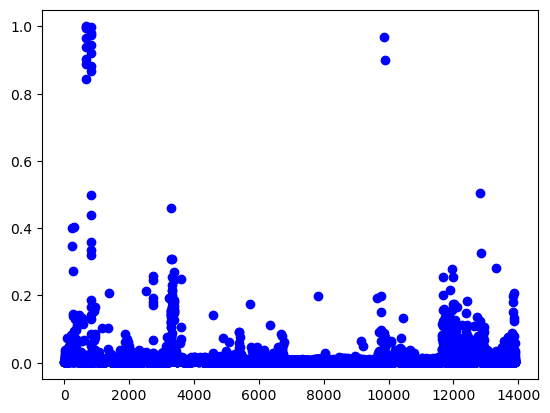

In [10]:
# Plot leverage scores
import matplotlib.pyplot as plt

fi = fisher_info(params, 0.5)
leverage_scores = np.diag(params @ la.pinv(fi) @ params.T) / 0.5

for i in range(rows):
    plt.plot(i, leverage_scores[i], 'bo')
    
print(np.std(leverage_scores))

In [12]:
# OLS
beta_h = np.linalg.inv(params.T @ params) @ params.T @ y

# R^2
mu = np.mean(y)
tss = np.sum((y - mu)**2)
yhat = params @ beta_h
ss = np.sum((y - yhat)**2)
r2 = 1 - (ss/tss)

print("R^2: ", r2)

R^2:  0.9881420948408817


## Ignore from here again

In [173]:
print(hadamard(4))
print(la.matrix_rank(params))

[[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]
127


Extending data to powers of 2 type array

In [26]:
# Adding columns of 0 to nearest power of 2
extra = 2**(math.ceil(math.log2(c))) - c

params2 = np.hstack((params, np.zeros((rows, extra))))

Hadamard Transform

In [ ]:
c2 = 2**math.ceil(math.log2(c))
r = 1024

# Random D matrix
diags = np.random.choice([-1, 1], size=(c2,))
D = np.diag(diags)
# print(D.shape)

# 16*16 Hadamard Matrix
H_16 = hadamard(2**c2)/np.sqrt(2**c2)
print(la.det(H_16))
# print(H_16.shape)

# Randomly sampling r columns from d*d I
P = rng.choice(np.eye(c2), size=(r)).T
# print(P.shape)

R1 = np.sqrt(c2/r) * D @ H_16
R = np.sqrt(c2/r) * D @ H_16 @ P

X_r = params2 @ R
beta_R = (weights.T @ P).T

X_t_no_sampling = params2 @ R1

Tests on Transformed Matrix

In [ ]:
print(np.linalg.det(fisher_info(X_r, 0.5)))
print(np.linalg.matrix_rank(X_r))

### A sort of example of what happens with lev scores when HT on columns

0.010429553216135127


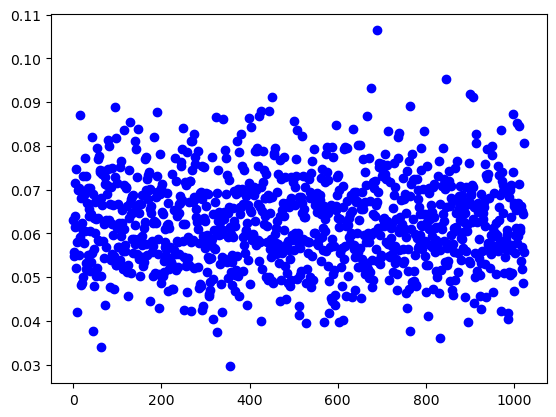

In [149]:
# Plot leverage scores
import matplotlib.pyplot as plt

fi = fisher_info(X_t_no_sampling, 0.5)
l2 = np.diag(X_t_no_sampling @ la.pinv(fi) @ X_t_no_sampling.T) / 0.5

for i in range(rows):
    plt.plot(i, l2[i], 'bo')
    
print(np.std(l2))

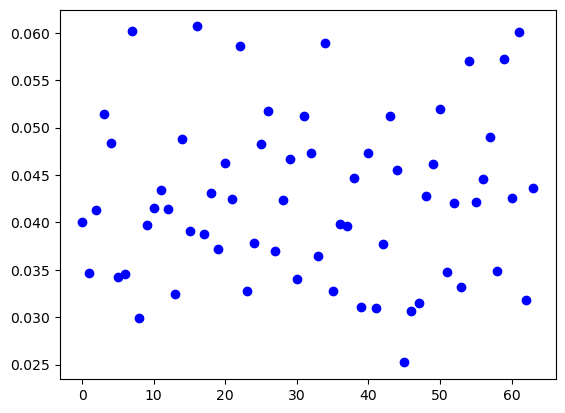

In [150]:
# Plot leverage scores
import matplotlib.pyplot as plt

fi = fisher_info(X_r, 0.5)
leverage_scores = np.diag(X_r @ la.pinv(fi) @ X_r.T) / 0.5

for i in range(r):
    plt.plot(i, leverage_scores[i], 'bo')

## HT on Rows

In [15]:
# Pad rows to params
r_extra = 2**(math.ceil(math.log2(rows))) - rows
rows2 = rows + r_extra

params3 = np.pad(params2, ((0, r_extra), (0, 0)), mode='constant')
print(params3.shape)

y3 = np.pad(y, (0, r_extra), mode='constant')

(16384, 128)


In [30]:
r = 1024

# Random D matrix
diags = np.random.choice([-1, 1], size=(rows2,))
D = np.diag(diags)
# print(D.shape)

# 16*16 Hadamard Matrix
H_16 = hadamard(rows2)/np.sqrt(rows2)
# print(la.det(H_16))
# print(H_16.shape)

# Randomly sampling r columns from d*d I
P = rng.choice(np.eye(rows2), size=(r))
# print(P.shape)

# R1 = np.sqrt(c2/r) * D @ H_16
# R = np.sqrt(c2/r) * D @ H_16 @ P

X_proj = H_16 @ D @ params3

X_r = P @ X_proj
beta_r3 = np.linalg.pinv(X_r) @ P @ H_16 @ D @ y3

In [239]:
P = rng.choice(np.eye(rows2), size=(r))


In [240]:
y_r3 = P @ y3
X_r3 = P @ params3

mu3 = np.mean(y_r3)
tss = np.sum((y_r3 - mu3)**2)
yhat = X_r3 @ beta_r3
ss = np.sum((y_r3 - yhat)**2)
r2 = 1 - (ss/tss)
print("R^2: ", r2)

R^2:  0.9925018854603951


In [234]:
# beta_r on entire thing
mu3 = np.mean(y3)
tss = np.sum((y3 - mu3)**2)
yhat3 = params3 @ beta_r3
ss = np.sum((y3 - yhat3)**2)
r2 = 1 - ss/tss
print("R^2 full:", r2)

R^2 full: 0.9877505868208026


0.0008797287486937323


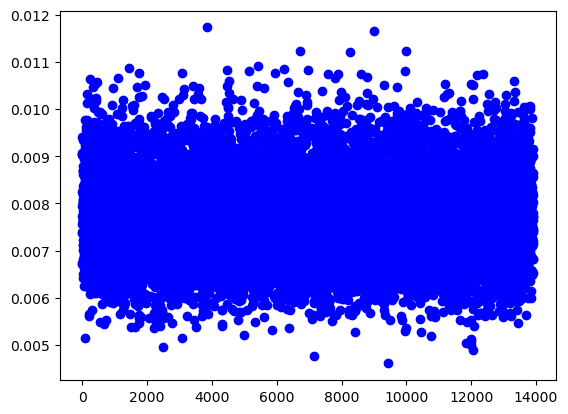

In [31]:
# Plot leverage scores
import matplotlib.pyplot as plt

fi = fisher_info(X_proj, 0.5)
leverage_scores = np.diag(X_proj @ la.pinv(fi) @ X_proj.T) / 0.5

for i in range(rows):
    plt.plot(i, leverage_scores[i], 'bo')
    
print(np.std(leverage_scores))

In [36]:
r2s = []
f1s = []

for i in range(2, 11):

    r = 2**i
    
    P = rng.choice(np.eye(rows2), size=(r))

    X_r = P @ X_proj
    beta_r3 = np.linalg.pinv(X_r) @ P @ H_16 @ D @ y3

    # beta_r on entire thing
    mu3 = np.mean(y3)
    tss = np.sum((y3 - mu3)**2)
    yhat3 = params3 @ beta_r3
    ss = np.sum((y3 - yhat3)**2)
    r2 = 1 - ss/tss
    print("r = ", 2**i, "- R^2 full:", r2)
    
    r2s.append(r2)
    
    ## Remove redundant rows in X_r and make X_r_unique
    X_r_unique = np.unique(X_r, axis=0)
    
    f1s.append(np.linalg.det(fisher_info(X_r_unique, 0.5)))
    

r =  4 - R^2 full: -2.4135577305848988
r =  8 - R^2 full: -0.9537272238784764
r =  16 - R^2 full: -2.6998306455133743
r =  32 - R^2 full: 0.7302405945172379
r =  64 - R^2 full: 0.9010056089403768
r =  128 - R^2 full: -0.21611948973563222
r =  256 - R^2 full: 0.9732473263682565
r =  512 - R^2 full: 0.985471622342972
r =  1024 - R^2 full: 0.9879724657813476


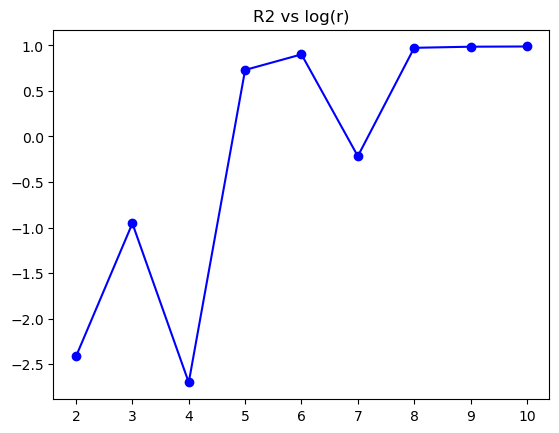

In [37]:
plt.title("R2 vs log(r)")
plt.plot(range(2, 11), r2s, 'bo-')
plt.show()

**There seems to be a drop in R^2 at 128 everytime I run** 

Prob because we sample quite a bit of the padded rows??

In [39]:
print(f1s)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## IBOSS Stuff

In [56]:
# Read from chem_data
chem_data = pd.read_csv('C:\\Users\\arjun\\OneDrive\\Desktop\\Random\\Math Club\\Sublime App\\chem_data.csv')
# Last col is response
params = chem_data.to_numpy()[:, :-1]
y = chem_data.to_numpy()[:, -1]
rows, c = params.shape

Unexplained variance from Chem_Data

In [57]:
'''
DON'T KEEP RUNNING THIS 
PARAMS WILL KEEP GOING DOWN THEN
'''
params = params/10

# Find unexplained error variance
error_variance = np.var(y - params @ np.linalg.lstsq(params, y, rcond=None)[0])
print(error_variance)


5.208511991767062


In [ ]:
print(np.linalg.det(fisher_info(params, error_variance)))

7.088848566361457e+243


In [68]:
p = c

def iboss(params, k):
    r = k//(2*c)
    selected_X = np.array([]).reshape(0, c)
    selected_y = np.array([])
    
    for i in range(c):
        sorted_indices = np.argsort(params[:, i])
        for j in range(r):
            selected_X = np.vstack((selected_X, params[sorted_indices[j], :]))
            selected_y = np.append(selected_y, y[sorted_indices[j]])
            selected_X = np.vstack((selected_X, params[sorted_indices[-(j+1)], :]))
            selected_y = np.append(selected_y, y[sorted_indices[-(j+1)]])
        
    return selected_X, selected_y
        

In [72]:
X_iboss, y_iboss = iboss(params, 256)
print(np.linalg.det(fisher_info(X_iboss, error_variance)))

-0.0


In [96]:
f1_iboss = []
r2_iboss = []

for i in range(2, 14):
    k = 2**i
    
    X_iboss, y_iboss = iboss(params, k)
    beta_iboss = np.linalg.pinv(X_iboss) @ y_iboss

    # beta_r on entire thing
    mu_iboss = np.mean(y)
    tss = np.sum((y - mu_iboss)**2)
    yhat_iboss = params @ beta_iboss
    ss = np.sum((y - yhat_iboss)**2)
    r2_ib = 1 - ss/tss
    print("k = ", 2**i, "- R^2 full:", r2_ib)
    
    r2_iboss.append(r2_ib)
    f1_iboss.append(np.linalg.det(fisher_info(X_iboss, error_variance)))

k =  4 - R^2 full: -0.5894490620540285
k =  8 - R^2 full: -0.5894490620540285
k =  16 - R^2 full: -0.5894490620540285
k =  32 - R^2 full: -0.5894490620540285
k =  64 - R^2 full: -0.5894490620540285
k =  128 - R^2 full: -0.5894490620540285
k =  256 - R^2 full: 0.6945235650840518
k =  512 - R^2 full: -1.808791168498566
k =  1024 - R^2 full: 0.5578297367591734
k =  2048 - R^2 full: 0.8306741461352074
k =  4096 - R^2 full: 0.8940786603963253
k =  8192 - R^2 full: 0.9325449343827031


In [97]:
print(f1_iboss)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, -3.5290076401861224e-82, 7.82072642093217e+139, 5.77330418932024e+194, 7.430677739267805e+240, 2.8438477770944614e+278]


C:\Users\arjun\AppData\Local\Temp\ipykernel_9640\3135770362.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(range(2, 14), np.log(np.abs(f1_iboss)), 'bo-')


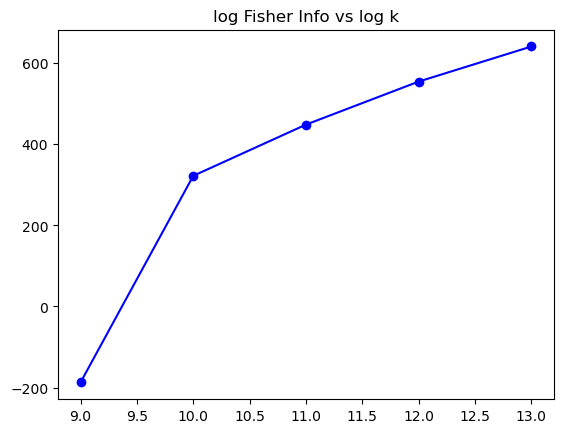

C:\Users\arjun\AppData\Local\Temp\ipykernel_9640\3135770362.py:5: RuntimeWarning: divide by zero encountered in log
  log_f1 = np.log(np.abs(f1_iboss))


In [121]:
plt.title("log Fisher Info vs log k")
plt.plot(range(2, 14), np.log(np.abs(f1_iboss)), 'bo-')
plt.show()

log_f1 = np.log(np.abs(f1_iboss))


### Is it linear after a point??

In [128]:
print('Approx slope of log FI vs log k at higher k')
print((log_f1[-1] - log_f1[-4])/3)
print()
print(p+1)

Approx slope of log FI vs log k at higher k
106.3492361565024

128


$$\log U = (p+1) \log k - p \log 4 - (p+1) \log \sigma^2 + 2 \sum \log (z_{n, j} - z_{1, j})$$

So the slope wrt log k is just (p+1) = **128**...106 seems to be smw close to 128 no?

In [133]:
const = -p*np.log(4) - (p+1)*np.log(error_variance)
for i in range(p):
    const += 2*np.log(np.max(params[:, i]) - np.min(params[:, i]))
    
print(const)

f1_upper_log = []
ratio = []

for i in range(2, 14):
    k = 2**i
    try:
        f1_upper_log.append(const + (p+1)*np.log(k))
    except:
        pass

494.45944578587273


C:\Users\arjun\AppData\Local\Temp\ipykernel_9640\130298927.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(range(2, 14), np.log(np.abs(f1_iboss)), 'bo-')


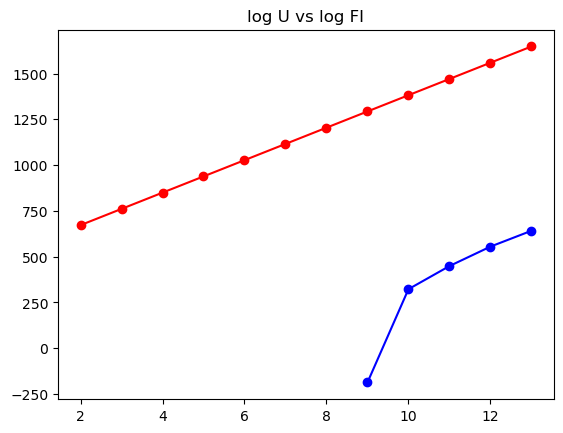

In [136]:
plt.title("log U vs log FI")
plt.plot(range(2, 14), np.log(np.abs(f1_iboss)), 'bo-')
plt.plot(range(2, 14), f1_upper_log, 'ro-')
plt.show()


**log U - log FI is more than 1000 so very less compared to U**

### R2 and FI

C:\Users\arjun\AppData\Local\Temp\ipykernel_9640\1181969495.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(r2_iboss, np.log(np.abs(f1_iboss)), 'bo-')


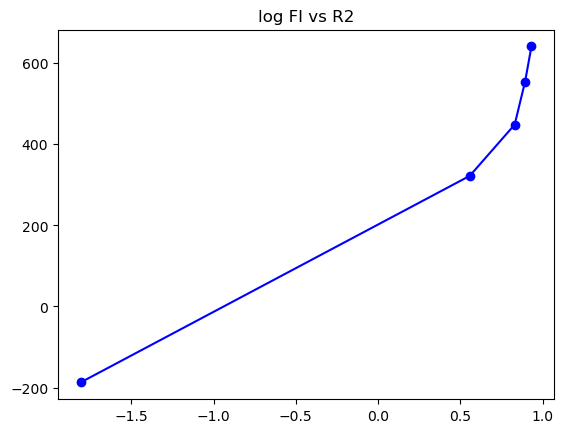

In [118]:
plt.title("log FI vs R2")
plt.plot(r2_iboss, np.log(np.abs(f1_iboss)), 'bo-')
plt.show()

**(First few matrices are non-invertible ig)**

### Fischer-Info Bounds

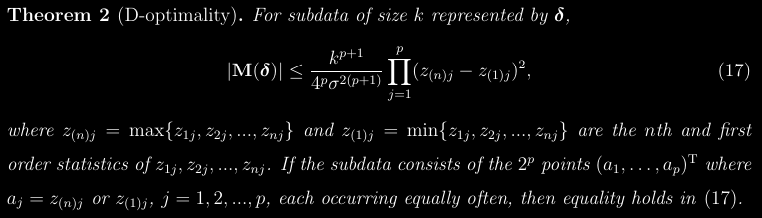

In [90]:
const = 1
for i in range(p):
    const *= (np.max(params[:, i]) - np.min(params[:, i]))**2
    
print(const)

inf


C:\Users\arjun\AppData\Local\Temp\ipykernel_9640\816970667.py:3: RuntimeWarning: overflow encountered in scalar multiply
  const *= (np.max(params[:, i]) - np.min(params[:, i]))**2


In [91]:
f1_upper = []
ratio = []

for i in range(2, 14):
    k = 2**i
    try:
        f1_upper.append(const * 4 * (k/(4*error_variance))**(p+1))
    except:
        f1_upper.append(float('inf'))
        
    ratio.append(f1_iboss[i-2]/f1_upper[i-2])

C:\Users\arjun\AppData\Local\Temp\ipykernel_9640\467812374.py:7: RuntimeWarning: overflow encountered in scalar power
  f1_upper.append(const * 4 * (k/(4*error_variance))**(p+1))


In [94]:
# plt.plot([2**i for i in range(2, 14)], ratio, 'bo-')
print(ratio)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, -0.0, 0.0, 0.0, 0.0, 0.0]


**Ratio of FI observed vs FI upper bound is v low**

### **Ignore**

In [15]:
import scipy.linalg

@njit
def shrt_run(r_n):
    XT = params.T
    rt, ct = (XT.shape)

    # Random D matrix
    diags = np.random.choice([-1, 1], size=(ct,))
    D = np.diag(diags)
    # print(D.shape)

    # 16*16 Hadamard Matrix
    H_16 = scipy.linalg.hadamard(ct)/np.sqrt(ct)
    # print(la.det(H_16))
    # print(H_16.shape)

    # Randomly sampling r columns from d*d I
    P = rng.choice(np.eye(ct), size=(r_n)).T
    # print(P.shape)

    R = np.sqrt(ct/r_n) * D @ H_16 @ P

    X_n = (params.T @ R).T
    y_n = (weights.T @ params.T @ R).T + rng.normal(loc=0.0, scale=0.5, size=(r_n,))
    
    i = fisher_info(X_n, 0.5)
    
    # OLS and Stuff
    beta_n = la.inv(X_n.T @ X_n) @ X_n.T @ y_n
    yhat_n = X_n @ beta_n
    ss_n = np.sum((y_n - yhat_n)**2)
    tss_n = np.sum((y_n - np.mean(y_n))**2)
    r2_n = 1 - (ss_n/tss_n)
    
    return la.det(i), r2_n